In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
## CLAUDE SAID IT DOESNT NEED IT ANYMORE

FILE = '../ha-1sec-full-rl-v4.pqt'
PRICE_COL = 'Close'
OUT_DIR = 'e3_out'
THETA_PCT = np.array([0.01, 0.02, 0.04, 0.08, 0.16, 0.32])
TAUS = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256, 512])
MIN_COUNT = 5
ROLL = 21

os.makedirs(OUT_DIR, exist_ok=True)
df = pd.read_parquet(FILE, columns=['date', PRICE_COL])
logp = np.log(df[PRICE_COL].to_numpy(np.float64))
dates = df['date'].to_numpy()
del df

day_starts = np.flatnonzero(np.r_[True, dates[1:] != dates[:-1]])
day_bounds = np.r_[day_starts, len(dates)]
day_list = dates[day_starts]
thetas = np.log1p(THETA_PCT / 100.0)

In [4]:
def extrema(x):
    keep = np.r_[True, np.diff(x) != 0]
    x = x[keep]
    n = x.size
    if n < 3:
        return x
    s = np.sign(np.diff(x))
    m = np.r_[True, s[1:] != s[:-1], True]
    return x[m]


def dc_count(x, th):
    up = True
    ext = x[0]
    c = 0
    for v in x[1:]:
        if up:
            if v > ext:
                ext = v
            elif ext - v >= th:
                c += 1
                up = False
                ext = v
        else:
            if v < ext:
                ext = v
            elif v - ext >= th:
                c += 1
                up = True
                ext = v
    return c

100/1158 days
200/1158 days
300/1158 days
400/1158 days
500/1158 days
600/1158 days
700/1158 days
800/1158 days
900/1158 days
1000/1158 days
1100/1158 days

days: 1158  alpha fitted: 1158
alpha: mean=-1.574 std=0.114  p25=-1.641 med=-1.580 p75=-1.510   (Brownian = -2)
hurst: mean=0.521 std=0.021  p25=0.508 med=0.521 p75=0.534   (Brownian = 0.5)
corr(alpha, hurst) = 0.282


/tmp/ipykernel_40289/1415227024.py:40: RuntimeWarning: divide by zero encountered in log
  gm = np.exp(np.nanmean(np.where(cnt > 0, np.log(cnt), np.nan), axis=0))


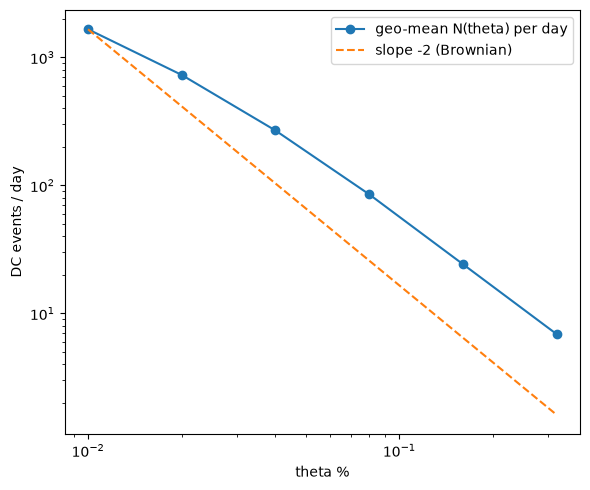

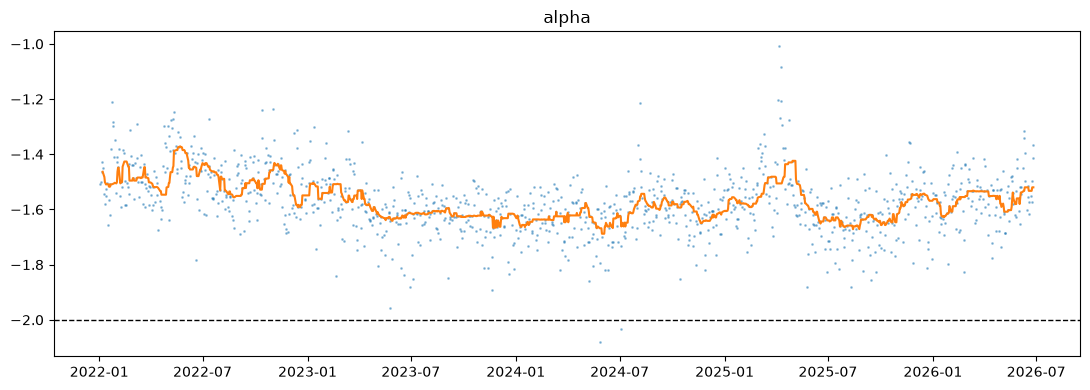

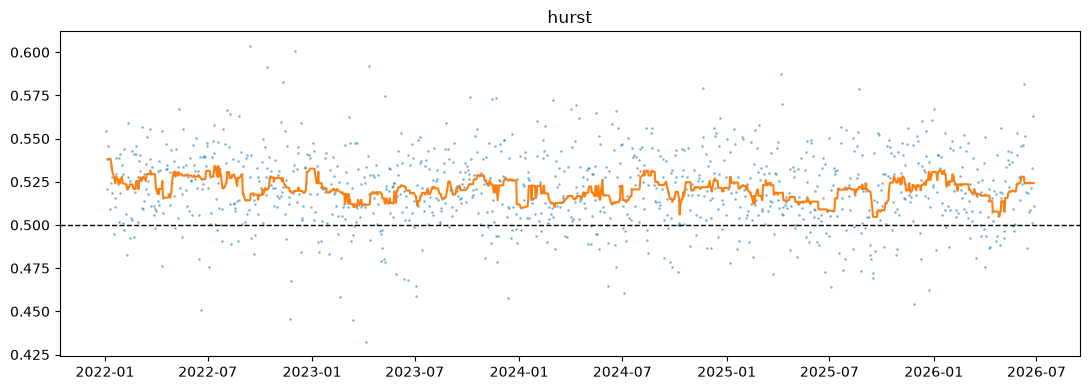

In [5]:
rows = []
for d in range(len(day_list)):
    x = logp[day_bounds[d]:day_bounds[d + 1]]
    e = extrema(x)
    counts = np.array([dc_count(e, t) for t in thetas])
    ok = counts >= MIN_COUNT
    if ok.sum() >= 3:
        lt = np.log(thetas[ok])
        lc = np.log(counts[ok].astype(np.float64))
        slope, intercept = np.polyfit(lt, lc, 1)
        resid = lc - (slope * lt + intercept)
        r2 = 1.0 - resid.var() / lc.var() if lc.var() > 0 else np.nan
    else:
        slope = r2 = np.nan
    v = np.array([np.mean((x[t:] - x[:-t]) ** 2) for t in TAUS if t < x.size])
    tt = TAUS[:v.size]
    if v.size >= 3 and np.all(v > 0):
        h = np.polyfit(np.log(tt), np.log(v), 1)[0] / 2.0
    else:
        h = np.nan
    rows.append((day_list[d], *counts, slope, r2, h))
    if (d + 1) % 100 == 0:
        print(f"{d + 1}/{len(day_list)} days", flush=True)

cols = ['date'] + [f"n_{t:g}" for t in THETA_PCT] + ['alpha', 'r2', 'hurst']
res = pd.DataFrame(rows, columns=cols)
res.to_csv(os.path.join(OUT_DIR, 'e3_daily.csv'), index=False)

a = res['alpha'].dropna()
h = res['hurst'].dropna()
print(f"\ndays: {len(res)}  alpha fitted: {len(a)}")
print(f"alpha: mean={a.mean():.3f} std={a.std():.3f}  "
      f"p25={a.quantile(.25):.3f} med={a.median():.3f} p75={a.quantile(.75):.3f}   (Brownian = -2)")
print(f"hurst: mean={h.mean():.3f} std={h.std():.3f}  "
      f"p25={h.quantile(.25):.3f} med={h.median():.3f} p75={h.quantile(.75):.3f}   (Brownian = 0.5)")
both = res.dropna(subset=['alpha', 'hurst'])
print(f"corr(alpha, hurst) = {np.corrcoef(both['alpha'], both['hurst'])[0, 1]:.3f}")

cnt = res[[f"n_{t:g}" for t in THETA_PCT]].to_numpy(np.float64)
gm = np.exp(np.nanmean(np.where(cnt > 0, np.log(cnt), np.nan), axis=0))
fig, ax = plt.subplots(figsize=(6, 5))
ax.loglog(THETA_PCT, gm, 'o-', label='geo-mean N(theta) per day')
ax.loglog(THETA_PCT, gm[0] * (THETA_PCT / THETA_PCT[0]) ** -2.0, '--', label='slope -2 (Brownian)')
ax.set_xlabel('theta %')
ax.set_ylabel('DC events / day')
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'dc_scaling.png'), dpi=130)

for col, refv, fname in (('alpha', -2.0, 'alpha_timeline.png'),
                         ('hurst', 0.5, 'hurst_timeline.png')):
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(res['date'], res[col], '.', ms=2, alpha=0.4)
    ax.plot(res['date'], res[col].rolling(ROLL, min_periods=5).median(), lw=1.5)
    ax.axhline(refv, ls='--', c='k', lw=1)
    ax.set_title(col)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, fname), dpi=130)
plt.show()